Aluno:Igor Fonseca Jorge

In [2]:
#Importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sklearn

from sklearn.model_selection import (train_test_split, cross_val_score, GridSearchCV,
                                     validation_curve, learning_curve)
from sklearn.tree import (DecisionTreeRegressor, DecisionTreeClassifier,
                          plot_tree, export_text)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                             accuracy_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Configuração para exibição limpa no console
pd.set_option('display.max_columns', None)

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid", palette="deep")

print("Versão do scikit-learn:", sklearn.__version__)

Versão do scikit-learn: 1.6.1



CARGA E PROCESSAMENTO INICIAL DOS DADOS (KAGGLE)

In [5]:
print("\n Carregando os arquivos originais do UNSW-NB15...")
try:
  # Lendo as partições oficiais do Kaggle
  train_df = pd.read_csv('/content/UNSW_NB15_training-set.csv')
  test_df = pd.read_csv('/content/UNSW_NB15_testing-set.csv')

  # Unificando temporariamente para aplicar o mesmo pré-processamento nas colunas textuais
  df = pd.concat([train_df, test_df], axis =0).reset_index(drop = True)
  print(f"   -> Sucesso! Base unificada com {df.shape[0]} linhas e {df.shape[1]} colunas.")
except FileNotFoundError:
  raise FileNotFoundError("ERRO: Certifica-te de que os arquivos 'UNSW_NB15_training-set.csv' e 'UNSW_NB15_testing-set.csv' foram carregados no painel lateral do teu Colab.")
#mostrar dataset de Cyber Range da Australian Defence Force Academy (UNSW Canberra)
display(df.head())


 Carregando os arquivos originais do UNSW-NB15...
   -> Sucesso! Base unificada com 257673 linhas e 45 colunas.


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


In [6]:
# Removendo colunas de identificação e redundâncias óbvias (como a label binária, já que o alvo é attack_cat)
colunas_para_remover = ['id','label']

df.drop(columns =[col for col in colunas_para_remover if col in df.columns],errors= 'ignore',inplace=True)

# Limpeza física: Substituir infinitos por NaN e preencher com a mediana
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.fillna(df.median(numeric_only=True))

display(df.head())


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal


ENGENHARIA DE RECURSOS (LABEL ENCODING)

In [7]:
# Identificando as 3 colunas de texto técnicas observadas nos logs de rede
colunas_texto = ['proto','service','state']
for col in colunas_texto:
  if col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Tratamento estrito da Variável Alvo (Target)
le_target = LabelEncoder()
df['attack_cat'] = le_target.fit_transform(df['attack_cat'].astype(str))

# Separação das matrizes preditoras (X) e do vetor alvo (y)
X = df.drop(columns=['attack_cat'])
y = df['attack_cat']

#Tratamento de nulos
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

*PADRONIZAÇÃO* E REDUÇÃO DE DIMENSIONALIDADE (PCA)

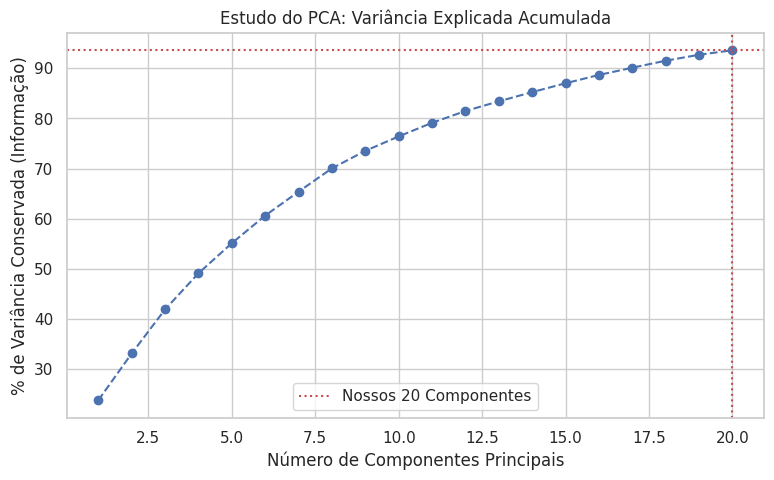

   -> Variância Explicada Retida com 20 componentes: 93.60%


In [8]:
# O PCA exige dados normalizados (Média=0, Variância=1) para não priorizar grandezas absolutas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Aplicando o PCA para extrair as n componentes principais que absorvem a maior variância das 43 originais
n_components =20
pca = PCA(n_components=n_components, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

variancia_acumulada = np.cumsum(pca.explained_variance_ratio_) * 100

# 📊 NOVO GRÁFICO: Curva de Variância Explicada do PCA
plt.figure(figsize=(9, 5))

plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o', linestyle='--', color='b')
plt.axvline(x=n_components, color='r', linestyle=':', label=f'Nossos {n_components} Componentes')
plt.axhline(y=variancia_acumulada[n_components -1], color='r', linestyle=':')
plt.title('Estudo do PCA: Variância Explicada Acumulada')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('% de Variância Conservada (Informação)')
plt.legend()
plt.show()

print(f"   -> Variância Explicada Retida com {n_components} componentes: {variancia_acumulada[n_components -1]:.2f}%")

DIVISÃO HOLDOUT (TREINO E TESTE)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)
resultados_globais = {}

REGRESSÃO COM ARVORE DE DECISÃO

TREINAMENTO - REGRESSÃO LOGÍSTICA

🤖 Iniciando Grid Search para Regressão Logística (usando os 20 componentes)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



✅ RESULTADOS REGRESSÃO LOGÍSTICA:
   - Melhores Parâmetros: {'C': 1.0}
   - Tempo: 27.54 min | ACURÁCIA: 68.56% | F1-Score Macro: 32.95%


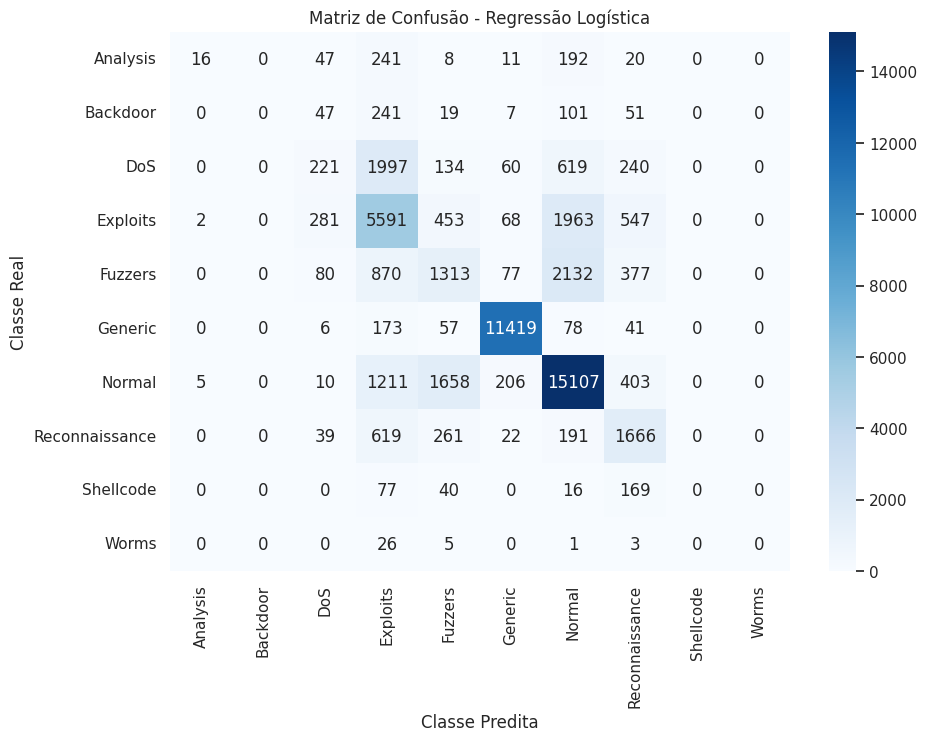

In [12]:
from sklearn.metrics import confusion_matrix

nome = 'Regressão Logística'
print(f"🤖 Iniciando Grid Search para {nome} (usando os 20 componentes)...")
t_inicio = time.time()

# Instancia o modelo linear. Usamos 'saga' e max_iter=1000 para convergir bem com PCA
lr_modelo = LogisticRegression(random_state=SEED, solver='saga', max_iter=1000)

# Hiperparâmetros para o Fine-Tuning exigido pelo professor
param_grid_lr = {'C': [0.1, 1.0]}

# Grid Search com Validação Cruzada (3 folds) focado na sua métrica principal: f1_macro
grid_lr = GridSearchCV(lr_modelo, param_grid_lr, cv=3, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train, y_train)

tempo_gasto = (time.time() - t_inicio) / 60

# Predições no conjunto de teste
preds = grid_lr.best_estimator_.predict(X_test)

# Cálculo das métricas ideais que definimos para o problema
acuracia = accuracy_score(y_test, preds)
f1_macro = f1_score(y_test, preds, average='macro')

print(f"\n✅ RESULTADOS {nome.upper()}:")
print(f"   - Melhores Parâmetros: {grid_lr.best_params_}")
print(f"   - Tempo: {tempo_gasto:.2f} min | ACURÁCIA: {acuracia*100:.2f}% | F1-Score Macro: {f1_macro*100:.2f}%")

# Salva os resultados no nosso dicionário global para o quadro comparativo final
resultados_globais[nome] = {'Acurácia': acuracia, 'F1-Score': f1_macro, 'Tempo (Min)': round(tempo_gasto, 2)}

# 📊 MTRICA VISUAL: Matriz de Confusão Estilizada
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Matriz de Confusão - {nome}')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.grid(False) # Garante que o grid do seaborn não risque o meio do mapa de calor
plt.show()

TREINAMENTO - ÁRVORE DE DECISÃO

🤖 Iniciando Grid Search para Árvore de Decisão...

✅ RESULTADOS ÁRVORE DE DECISÃO:
   - Melhores Parâmetros: {'max_depth': None, 'min_samples_split': 2}
   - Tempo: 2.40 min | ACURÁCIA: 76.19% | F1-Score Macro: 46.77%


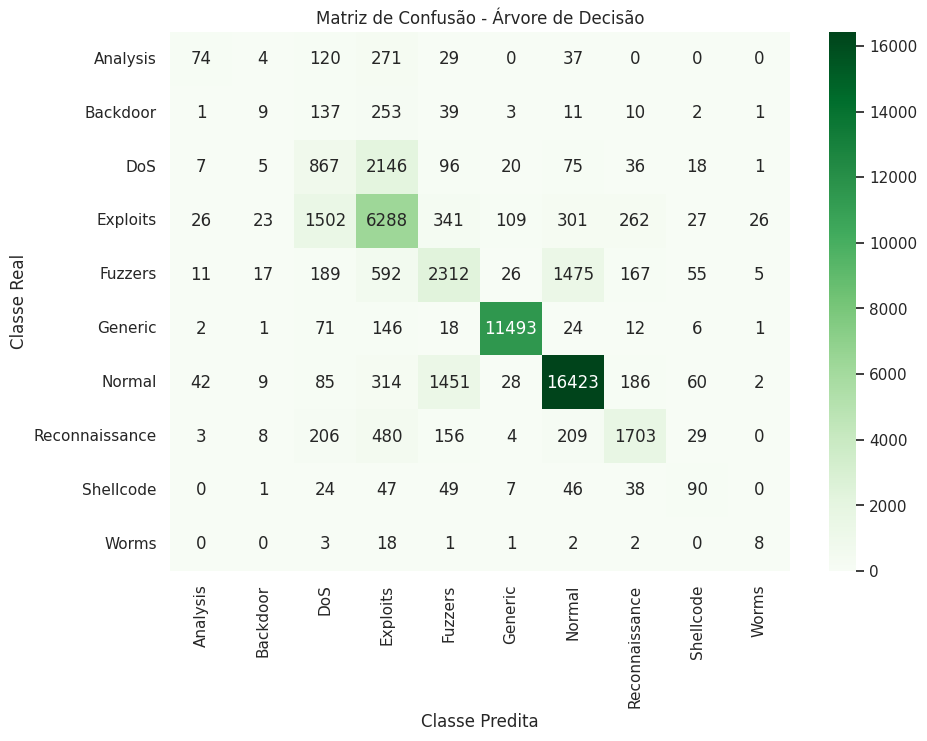

In [13]:
nome = 'Árvore de Decisão'
print(f"🤖 Iniciando Grid Search para {nome}...")
t_inicio = time.time()

dt_modelo = DecisionTreeClassifier(random_state=SEED)

# Hiperparâmetros de profundidade para o Fine-Tuning
param_grid_dt = {
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_dt = GridSearchCV(dt_modelo, param_grid_dt, cv=3, scoring='f1_macro', n_jobs=-1)
grid_dt.fit(X_train, y_train)

tempo_gasto = (time.time() - t_inicio) / 60

preds = grid_dt.best_estimator_.predict(X_test)
acuracia = accuracy_score(y_test, preds)
f1_macro = f1_score(y_test, preds, average='macro')

print(f"\n✅ RESULTADOS {nome.upper()}:")
print(f"   - Melhores Parâmetros: {grid_dt.best_params_}")
print(f"   - Tempo: {tempo_gasto:.2f} min | ACURÁCIA: {acuracia*100:.2f}% | F1-Score Macro: {f1_macro*100:.2f}%")

resultados_globais[nome] = {'Acurácia': acuracia, 'F1-Score': f1_macro, 'Tempo (Min)': round(tempo_gasto, 2)}

# 📊 MATRIZ DE CONFUSÃO: Tons de verde para diferenciar o modelo
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Matriz de Confusão - {nome}')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.grid(False)
plt.show()

TREINAMENTO - RANDOM FOREST

🤖 Iniciando Grid Search para Random Forest. Pode demorar um pouco...

✅ RESULTADOS RANDOM FOREST:
   - Melhores Parâmetros: {'max_depth': 20, 'n_estimators': 100}
   - Tempo: 14.00 min | ACURÁCIA: 79.21% | F1-Score Macro: 48.83%


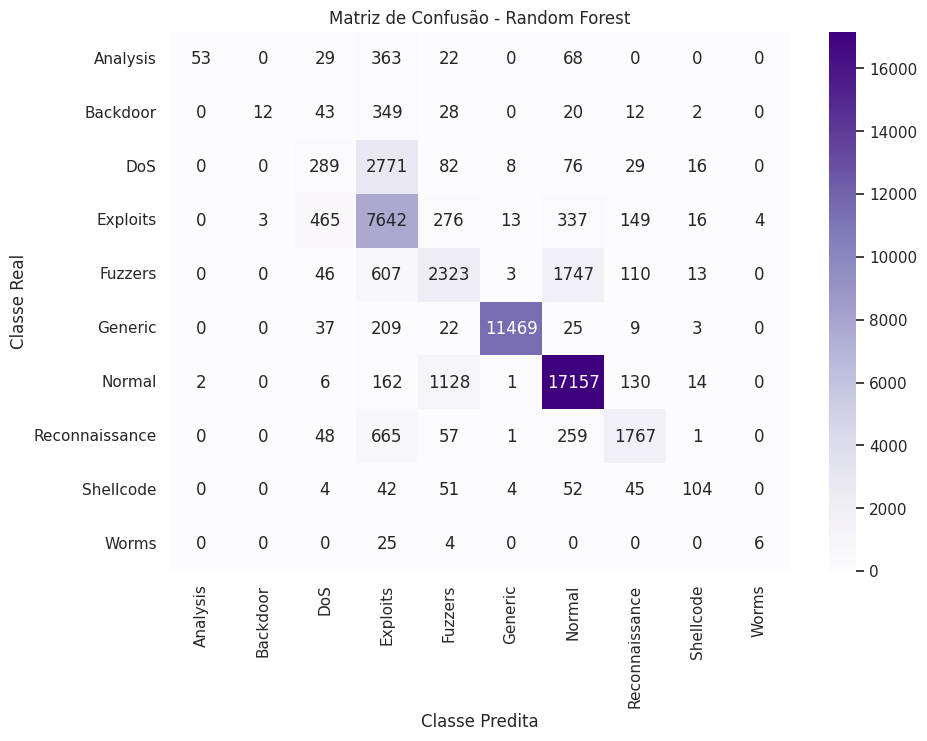

In [14]:
nome = 'Random Forest'
print(f"🤖 Iniciando Grid Search para {nome}. Pode demorar um pouco...")
t_inicio = time.time()

# Instancia o modelo ensemble usando n_jobs=-1 para usar todos os processadores do Colab
rf_modelo = RandomForestClassifier(random_state=SEED, n_jobs=-1)

# Hiperparâmetros estruturais para o fine-tuning
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

grid_rf = GridSearchCV(rf_modelo, param_grid_rf, cv=3, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)

tempo_gasto = (time.time() - t_inicio) / 60

# Predições e cálculo das métricas
preds = grid_rf.best_estimator_.predict(X_test)
acuracia = accuracy_score(y_test, preds)
f1_macro = f1_score(y_test, preds, average='macro')

print(f"\n✅ RESULTADOS {nome.upper()}:")
print(f"   - Melhores Parâmetros: {grid_rf.best_params_}")
print(f"   - Tempo: {tempo_gasto:.2f} min | ACURÁCIA: {acuracia*100:.2f}% | F1-Score Macro: {f1_macro*100:.2f}%")

# Salva no acumulador global
resultados_globais[nome] = {'Acurácia': acuracia, 'F1-Score': f1_macro, 'Tempo (Min)': round(tempo_gasto, 2)}

# 📊 MATRIZ DE CONFUSÃO: Tons de roxo/magenta para diferenciar o modelo
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Matriz de Confusão - {nome}')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.grid(False)
plt.show()

TREINAMENTO E GRÁFICO - XGBOOST

🤖 Iniciando Grid Search para XGBoost...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ RESULTADOS XGBOOST:
   - Melhores Parâmetros: {'max_depth': 10, 'n_estimators': 100}
   - Tempo: 6.88 min | ACURÁCIA: 79.05% | F1-Score Macro: 50.53%


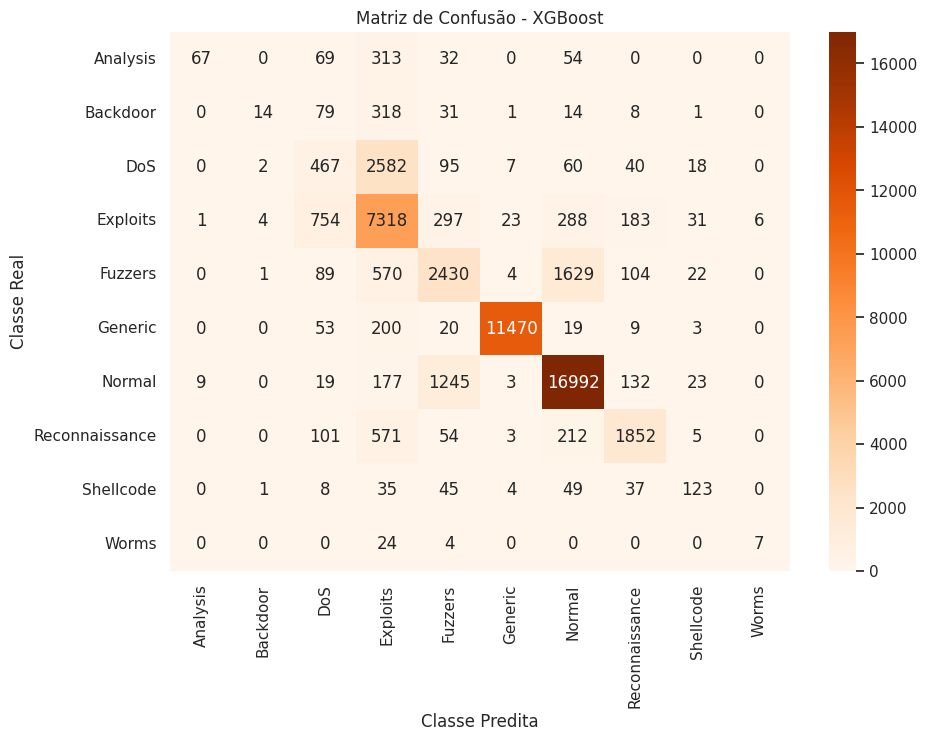

In [15]:
nome = 'XGBoost'
nome = 'XGBoost'
print(f"🤖 Iniciando Grid Search para {nome}...")
t_inicio = time.time()

# Instancia o XGBoost configurado para o nosso problema multiclasse
xgb_modelo = XGBClassifier(random_state=SEED, eval_metric='mlogloss', n_jobs=-1)

# Parâmetros de ajuste fino para controlar o aprendizado e profundidade
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [6, 10]
}

grid_xgb = GridSearchCV(xgb_modelo, param_grid_xgb, cv=3, scoring='f1_macro', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

tempo_gasto = (time.time() - t_inicio) / 60

# Predições e cálculo das métricas
preds = grid_xgb.best_estimator_.predict(X_test)
acuracia = accuracy_score(y_test, preds)
f1_macro = f1_score(y_test, preds, average='macro')

print(f"\n✅ RESULTADOS {nome.upper()}:")
print(f"   - Melhores Parâmetros: {grid_xgb.best_params_}")
print(f"   - Tempo: {tempo_gasto:.2f} min | ACURÁCIA: {acuracia*100:.2f}% | F1-Score Macro: {f1_macro*100:.2f}%")

# Salva no acumulador global
resultados_globais[nome] = {'Acurácia': acuracia, 'F1-Score': f1_macro, 'Tempo (Min)': round(tempo_gasto, 2)}

# 📊 MATRIZ DE CONFUSÃO: Tons de laranja para o XGBoost
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Matriz de Confusão - {nome}')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.grid(False)
plt.show()

QUADRO COMPARATIVO CONSOLIDADO

In [16]:
df_comparativo = pd.DataFrame.from_dict(resultados_globais, orient='index')

# Converte as taxas decimais para porcentagem
df_comparativo['Acurácia'] = df_comparativo['Acurácia'] * 100
df_comparativo['F1-Score'] = df_comparativo['F1-Score'] * 100

print("📊 QUADRO COMPARATIVO CONSOLIDADO (ORDENADO PELO F1-SCORE):")
df_ordenado = df_comparativo.sort_values(by='F1-Score', ascending=False)

# Aplica uma estilização visual elegante (Verde para os melhores resultados)
display(df_ordenado.style.format({
    'Acurácia': '{:.2f}%',
    'F1-Score': '{:.2f}%',
    'Tempo (Min)': '{:.2f} min'
}).highlight_max(subset=['Acurácia', 'F1-Score'], color='lightgreen')
  .highlight_min(subset=['Tempo (Min)'], color='lightgreen'))

📊 QUADRO COMPARATIVO CONSOLIDADO (ORDENADO PELO F1-SCORE):


,Acurácia,F1-Score,Tempo (Min)
XGBoost,79.05%,50.53%,6.88 min
Random Forest,79.21%,48.83%,14.00 min
Árvore de Decisão,76.19%,46.77%,2.40 min
Regressão Logística,68.56%,32.95%,27.54 min
